In [1]:
import pandas as pd
import numpy as np

In [154]:
# Set a random seed for reproducibility
np.random.seed(42)

# Define the number of records to create
num_records = 100

# Create sample data
car_makes = ['Toyota', 'Honda', 'Ford', 'BMW', 'Mercedes', 'Audi', 'Chevrolet', 'Nissan', 'Hyundai', 'Kia']
car_models = {
    'Toyota': ['Camry', 'Corolla', 'RAV4', 'Highlander', 'Tacoma'],
    'Honda': ['Civic', 'Accord', 'CR-V', 'Pilot', 'Odyssey'],
    'Ford': ['F-150', 'Escape', 'Explorer', 'Mustang', 'Focus'],
    'BMW': ['3 Series', '5 Series', 'X3', 'X5', '7 Series'],
    'Mercedes': ['C-Class', 'E-Class', 'GLC', 'GLE', 'S-Class'],
    'Audi': ['A3', 'A4', 'Q5', 'Q7', 'A6'],
    'Chevrolet': ['Silverado', 'Equinox', 'Malibu', 'Traverse', 'Tahoe'],
    'Nissan': ['Altima', 'Rogue', 'Sentra', 'Pathfinder', 'Murano'],
    'Hyundai': ['Elantra', 'Tucson', 'Santa Fe', 'Sonata', 'Kona'],
    'Kia': ['Forte', 'Sportage', 'Sorento', 'Telluride', 'Soul']
}

# Generate random data
makes = np.random.choice(car_makes, num_records)
models = [np.random.choice(car_models[make]) for make in makes]
years = np.random.randint(2010, 2024, num_records)
mileage = np.random.randint(1000, 150000, num_records)
conditions = np.random.choice(['Excellent', 'Good', 'Fair', 'Poor'], num_records, p=[0.3, 0.4, 0.2, 0.1])

# Generate prices based on make, year, and mileage
base_prices = {
    'Toyota': 25000, 'Honda': 24000, 'Ford': 27000, 'BMW': 45000, 
    'Mercedes': 50000, 'Audi': 42000, 'Chevrolet': 30000, 
    'Nissan': 23000, 'Hyundai': 22000, 'Kia': 21000
}

prices = []
for i in range(num_records):
    make = makes[i]
    year = years[i]
    miles = mileage[i]
    condition = conditions[i]
    
    # Base price for the make
    price = base_prices[make]
    
    # Adjust for year (newer cars cost more)
    price += (year - 2010) * 1000
    
    # Adjust for mileage (higher mileage reduces price)
    price -= (miles / 10000) * 1000
    
    # Adjust for condition
    condition_factors = {'Excellent': 1.1, 'Good': 1.0, 'Fair': 0.9, 'Poor': 0.7}
    price *= condition_factors[condition]
    
    # Add some random variation
    price *= np.random.uniform(0.9, 1.1)
    
    prices.append(max(round(price, 2), 5000))  # Ensure minimum price of $5000

# Create DataFrame
car_data = pd.DataFrame({
    'Make': makes,
    'Model': models,
    'Year': years,
    'Mileage': mileage,
    'Condition': conditions,
    'Price': prices
})

# Save to CSV
csv_filename = 'car_pricing_data.csv'
car_data.to_csv(csv_filename, index=False)

print(f"CSV file '{csv_filename}' created successfully with {num_records} records.")

# Display the first few rows of the dataset
car_data

CSV file 'car_pricing_data.csv' created successfully with 100 records.


,Make,Model,Year,Mileage,Condition,Price
0,Chevrolet,Traverse,2010,20830,Excellent,31337.87
1,BMW,5 Series,2018,149501,Poor,26921.01
2,Nissan,Altima,2021,138965,Good,18948.47
3,Mercedes,S-Class,2020,117381,Excellent,57825.61
4,Chevrolet,Malibu,2015,48333,Excellent,35050.24
...,...,...,...,...,...,...
95,Kia,Forte,2010,9308,Good,18394.42
96,Hyundai,Kona,2021,6949,Good,34738.72
97,Chevrolet,Traverse,2020,133222,Good,26953.05
98,Hyundai,Tucson,2012,101235,Excellent,14240.95


In [3]:
print(car_data)

         Make     Model  Year  Mileage  Condition     Price
0   Chevrolet  Traverse  2010    20830  Excellent  31337.87
1         BMW  5 Series  2018   149501       Poor  26921.01
2      Nissan    Altima  2021   138965       Good  18948.47
3    Mercedes   S-Class  2020   117381  Excellent  57825.61
4   Chevrolet    Malibu  2015    48333  Excellent  35050.24
..        ...       ...   ...      ...        ...       ...
95        Kia     Forte  2010     9308       Good  18394.42
96    Hyundai      Kona  2021     6949       Good  34738.72
97  Chevrolet  Traverse  2020   133222       Good  26953.05
98    Hyundai    Tucson  2012   101235  Excellent  14240.95
99     Nissan    Sentra  2015    75740  Excellent  22069.81

[100 rows x 6 columns]


In [157]:
df=pd.DataFrame(car_data)

In [5]:
df

,Make,Model,Year,Mileage,Condition,Price
0,Chevrolet,Traverse,2010,20830,Excellent,31337.87
1,BMW,5 Series,2018,149501,Poor,26921.01
2,Nissan,Altima,2021,138965,Good,18948.47
3,Mercedes,S-Class,2020,117381,Excellent,57825.61
4,Chevrolet,Malibu,2015,48333,Excellent,35050.24
...,...,...,...,...,...,...
95,Kia,Forte,2010,9308,Good,18394.42
96,Hyundai,Kona,2021,6949,Good,34738.72
97,Chevrolet,Traverse,2020,133222,Good,26953.05
98,Hyundai,Tucson,2012,101235,Excellent,14240.95


In [6]:
df.columns

Index(['Make', 'Model', 'Year', 'Mileage', 'Condition', 'Price'], dtype='object')

In [7]:
df.describe()

,Year,Mileage,Price
count,100.000000,100.000000,100.000000
mean,2015.620000,77173.160000,27331.329600
std,4.037151,44083.012574,12258.566302
min,2010.000000,3368.000000,8501.560000
25%,2012.000000,36289.750000,18353.932500
50%,2015.500000,83412.000000,25187.685000
75%,2018.250000,114897.000000,34019.305000
max,2023.000000,149501.000000,60736.030000


In [8]:
df[df['Mileage'] >= 17000 ]

,Make,Model,Year,Mileage,Condition,Price
0,Chevrolet,Traverse,2010,20830,Excellent,31337.87
1,BMW,5 Series,2018,149501,Poor,26921.01
2,Nissan,Altima,2021,138965,Good,18948.47
3,Mercedes,S-Class,2020,117381,Excellent,57825.61
4,Chevrolet,Malibu,2015,48333,Excellent,35050.24
...,...,...,...,...,...,...
93,Kia,Sorento,2012,91852,Good,14039.05
94,Chevrolet,Malibu,2010,33217,Poor,20240.42
97,Chevrolet,Traverse,2020,133222,Good,26953.05
98,Hyundai,Tucson,2012,101235,Excellent,14240.95


In [9]:
df.head(17)

,Make,Model,Year,Mileage,Condition,Price
0,Chevrolet,Traverse,2010,20830,Excellent,31337.87
1,BMW,5 Series,2018,149501,Poor,26921.01
2,Nissan,Altima,2021,138965,Good,18948.47
3,Mercedes,S-Class,2020,117381,Excellent,57825.61
4,Chevrolet,Malibu,2015,48333,Excellent,35050.24
5,Kia,Telluride,2022,135508,Excellent,19740.20
6,Ford,Explorer,2012,77213,Poor,16178.84
7,Chevrolet,Malibu,2013,137967,Good,21024.73
8,Nissan,Altima,2021,31746,Good,33882.86
9,Mercedes,GLC,2020,50377,Good,50080.23


In [10]:
df.tail(10)

,Make,Model,Year,Mileage,Condition,Price
90,Ford,Mustang,2017,104481,Excellent,23711.21
91,Toyota,Corolla,2017,113566,Poor,15723.55
92,Mercedes,GLE,2016,26945,Fair,47175.10
93,Kia,Sorento,2012,91852,Good,14039.05
94,Chevrolet,Malibu,2010,33217,Poor,20240.42
95,Kia,Forte,2010,9308,Good,18394.42
96,Hyundai,Kona,2021,6949,Good,34738.72
97,Chevrolet,Traverse,2020,133222,Good,26953.05
98,Hyundai,Tucson,2012,101235,Excellent,14240.95
99,Nissan,Sentra,2015,75740,Excellent,22069.81


In [11]:
df.head()

,Make,Model,Year,Mileage,Condition,Price
0,Chevrolet,Traverse,2010,20830,Excellent,31337.87
1,BMW,5 Series,2018,149501,Poor,26921.01
2,Nissan,Altima,2021,138965,Good,18948.47
3,Mercedes,S-Class,2020,117381,Excellent,57825.61
4,Chevrolet,Malibu,2015,48333,Excellent,35050.24


In [12]:
df.tail

<bound method NDFrame.tail of          Make     Model  Year  Mileage  Condition     Price
0   Chevrolet  Traverse  2010    20830  Excellent  31337.87
1         BMW  5 Series  2018   149501       Poor  26921.01
2      Nissan    Altima  2021   138965       Good  18948.47
3    Mercedes   S-Class  2020   117381  Excellent  57825.61
4   Chevrolet    Malibu  2015    48333  Excellent  35050.24
..        ...       ...   ...      ...        ...       ...
95        Kia     Forte  2010     9308       Good  18394.42
96    Hyundai      Kona  2021     6949       Good  34738.72
97  Chevrolet  Traverse  2020   133222       Good  26953.05
98    Hyundai    Tucson  2012   101235  Excellent  14240.95
99     Nissan    Sentra  2015    75740  Excellent  22069.81

[100 rows x 6 columns]>

In [20]:
df[df['Make'] == 'Honda']

,Make,Model,Year,Mileage,Condition,Price
16,Honda,Civic,2016,103946,Good,21043.92
19,Honda,Pilot,2010,125123,Good,10850.31
38,Honda,Civic,2013,37631,Poor,16052.59
41,Honda,Pilot,2011,12093,Good,24130.78
46,Honda,Accord,2014,11729,Fair,25018.61
53,Honda,Civic,2012,11647,Excellent,28969.48
56,Honda,Civic,2015,71316,Good,21092.89
62,Honda,CR-V,2010,125046,Excellent,11571.22
64,Honda,Pilot,2013,33097,Good,22348.52
72,Honda,Pilot,2012,56609,Good,18540.57


In [29]:
print(df[['Make','Year']]) # to access both columns with at a same time 

         Make  Year
0   Chevrolet  2010
1         BMW  2018
2      Nissan  2021
3    Mercedes  2020
4   Chevrolet  2015
..        ...   ...
95        Kia  2010
96    Hyundai  2021
97  Chevrolet  2020
98    Hyundai  2012
99     Nissan  2015

[100 rows x 2 columns]


In [31]:
df.iloc[:,[0,4]] # first and any column by mention index

,Make,Condition
0,Chevrolet,Excellent
1,BMW,Poor
2,Nissan,Good
3,Mercedes,Excellent
4,Chevrolet,Excellent
...,...,...
95,Kia,Good
96,Hyundai,Good
97,Chevrolet,Good
98,Hyundai,Excellent


In [40]:
df.loc[:, ['Make', 'Model']]

,Make,Model
0,Chevrolet,Traverse
1,BMW,5 Series
2,Nissan,Altima
3,Mercedes,S-Class
4,Chevrolet,Malibu
...,...,...
95,Kia,Forte
96,Hyundai,Kona
97,Chevrolet,Traverse
98,Hyundai,Tucson


In [41]:
df.sample()

,Make,Model,Year,Mileage,Condition,Price
82,Nissan,Rogue,2018,74523,Fair,20175.46


In [42]:
df.sample(2)

,Make,Model,Year,Mileage,Condition,Price
92,Mercedes,GLE,2016,26945,Fair,47175.10
64,Honda,Pilot,2013,33097,Good,22348.52


In [50]:
df[
    (df['Mileage'] >= 10000) &  (df['Mileage'] <= 70000) &
    (df['Price'] >= 20000.56) &(df['Price'] <= 50000)
    
]

,Make,Model,Year,Mileage,Condition,Price
0,Chevrolet,Traverse,2010,20830,Excellent,31337.87
4,Chevrolet,Malibu,2015,48333,Excellent,35050.24
8,Nissan,Altima,2021,31746,Good,33882.86
10,BMW,7 Series,2013,55045,Good,44510.09
20,Mercedes,S-Class,2017,44484,Poor,36025.76
23,Audi,Q7,2017,44525,Fair,40199.61
25,Toyota,Highlander,2020,34828,Good,32029.70
31,Ford,Focus,2023,66726,Excellent,35561.94
36,Hyundai,Tucson,2019,27641,Good,26816.90
41,Honda,Pilot,2011,12093,Good,24130.78


In [51]:
df.isnull() # its to detect null 

,Make,Model,Year,Mileage,Condition,Price
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
95,False,False,False,False,False,False
96,False,False,False,False,False,False
97,False,False,False,False,False,False
98,False,False,False,False,False,False


In [54]:
df.isnull().sum()

Make         0
Model        0
Year         0
Mileage      0
Condition    0
Price        0
dtype: int64

<Axes: >

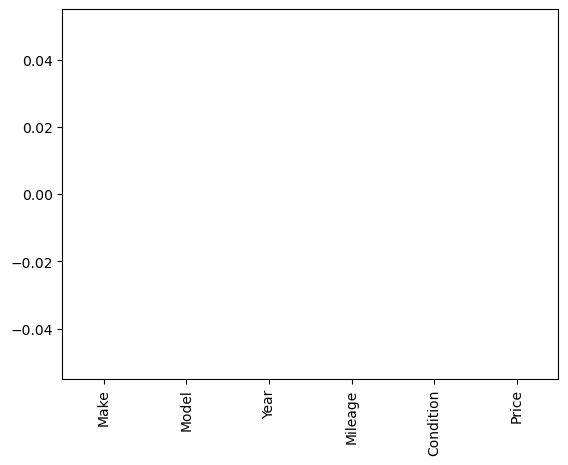

In [57]:
df.isnull().sum().plot(kind='bar')

<Axes: >

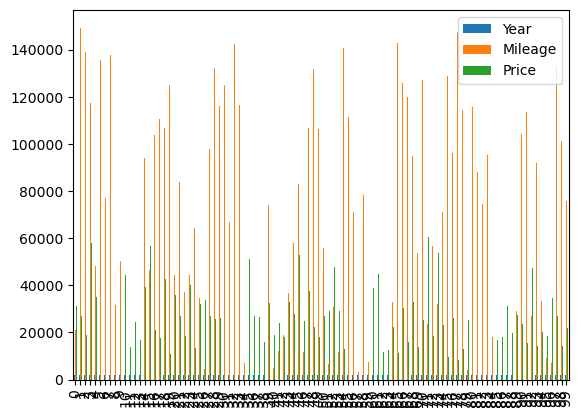

In [62]:
df.plot(kind='bar')

In [ ]:
df.notnull() # it is detect if there is any null it give false and if there is not null then it gives true 

<Axes: >

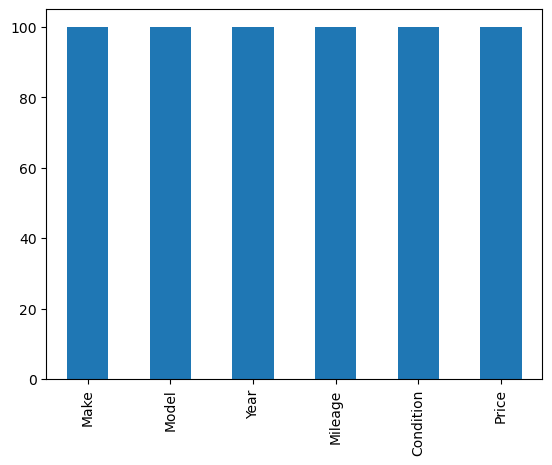

In [68]:
df.notnull().sum().plot(kind='bar') # this line mean that to first find out notnull value after that calculate the total sum of sum then draw on graph 

In [72]:
df.notnull().sum()*100/len(df)

Make         100.0
Model        100.0
Year         100.0
Mileage      100.0
Condition    100.0
Price        100.0
dtype: float64

In [78]:
df.isna().sum()*100/len(df)

Make         0.0
Model        0.0
Year         0.0
Mileage      0.0
Condition    0.0
Price        0.0
dtype: float64

In [82]:
df[['Make','Model']].unique()

AttributeError: 'DataFrame' object has no attribute 'unique'

In [83]:
df.value_counts()

Make      Model     Year  Mileage  Condition  Price   
Audi      A3        2020  88922    Good       44792.55    1
Kia       Soul      2021  4420     Good       33849.99    1
Mercedes  GLC       2020  50377    Good       50080.23    1
                    2019  142564   Excellent  51267.21    1
                    2014  83074    Excellent  52716.77    1
                                                         ..
Ford      Focus     2012  137672   Good       16660.58    1
          F-150     2018  55748    Good       26970.50    1
                    2010  87672    Good       17909.01    1
          Explorer  2012  116668   Poor       12088.75    1
Toyota    RAV4      2023  74847    Good       31142.58    1
Name: count, Length: 100, dtype: int64

In [84]:
df['Make'].str.upper()

0     CHEVROLET
1           BMW
2        NISSAN
3      MERCEDES
4     CHEVROLET
        ...    
95          KIA
96      HYUNDAI
97    CHEVROLET
98      HYUNDAI
99       NISSAN
Name: Make, Length: 100, dtype: object

In [85]:
df['Make'].str.lower()

0     chevrolet
1           bmw
2        nissan
3      mercedes
4     chevrolet
        ...    
95          kia
96      hyundai
97    chevrolet
98      hyundai
99       nissan
Name: Make, Length: 100, dtype: object

In [87]:
df['Make'].str.split(' ')

0     [Chevrolet]
1           [BMW]
2        [Nissan]
3      [Mercedes]
4     [Chevrolet]
         ...     
95          [Kia]
96      [Hyundai]
97    [Chevrolet]
98      [Hyundai]
99       [Nissan]
Name: Make, Length: 100, dtype: object

In [88]:
df

,Make,Model,Year,Mileage,Condition,Price
0,Chevrolet,Traverse,2010,20830,Excellent,31337.87
1,BMW,5 Series,2018,149501,Poor,26921.01
2,Nissan,Altima,2021,138965,Good,18948.47
3,Mercedes,S-Class,2020,117381,Excellent,57825.61
4,Chevrolet,Malibu,2015,48333,Excellent,35050.24
...,...,...,...,...,...,...
95,Kia,Forte,2010,9308,Good,18394.42
96,Hyundai,Kona,2021,6949,Good,34738.72
97,Chevrolet,Traverse,2020,133222,Good,26953.05
98,Hyundai,Tucson,2012,101235,Excellent,14240.95


In [111]:
data = 'chevrolet , 2010 , 31337.87'# it is use for double space and it takes single string variable and do manually and it doesnt effect on no split
fun = lambda x : x.split('  ')[0]

In [112]:
fun(data)

'chevrolet , 2010 , 31337.87'

In [113]:
df['Make'].apply(lambda x : x.split(' ')[0]) #it use for single space and it do each row of a dataframe columns  and it applied  row wise via apply and it do and give split and first word 

0     Chevrolet
1           BMW
2        Nissan
3      Mercedes
4     Chevrolet
        ...    
95          Kia
96      Hyundai
97    Chevrolet
98      Hyundai
99       Nissan
Name: Make, Length: 100, dtype: object

In [117]:
df['Make'].apply(lambda x : x.split(' ')[0].upper()).unique()

array(['CHEVROLET', 'BMW', 'NISSAN', 'MERCEDES', 'KIA', 'FORD', 'AUDI',
       'HONDA', 'TOYOTA', 'HYUNDAI'], dtype=object)

In [127]:
df['Make'] = df['Model'].apply(lambda x : x.split(' ')[0])

In [119]:
df

,Make,Model,Year,Mileage,Condition,Price
0,Traverse,Traverse,2010,20830,Excellent,31337.87
1,5,5 Series,2018,149501,Poor,26921.01
2,Altima,Altima,2021,138965,Good,18948.47
3,S-Class,S-Class,2020,117381,Excellent,57825.61
4,Malibu,Malibu,2015,48333,Excellent,35050.24
...,...,...,...,...,...,...
95,Forte,Forte,2010,9308,Good,18394.42
96,Kona,Kona,2021,6949,Good,34738.72
97,Traverse,Traverse,2020,133222,Good,26953.05
98,Tucson,Tucson,2012,101235,Excellent,14240.95


In [128]:
df['Make'].value_counts()

Make
Altima        5
7             5
Civic         4
Malibu        4
Forte         4
GLC           4
Pilot         4
Focus         4
Rogue         4
Traverse      3
Sonata        3
Kona          3
Silverado     3
Tucson        3
Sentra        3
Telluride     3
Q5            2
Elantra       2
Pathfinder    2
Camry         2
F-150         2
GLE           2
Sorento       2
E-Class       2
Highlander    2
S-Class       2
Explorer      2
RAV4          2
A4            2
Tahoe         1
Sportage      1
Mustang       1
Murano        1
Santa         1
3             1
CR-V          1
Accord        1
A3            1
Q7            1
X3            1
Soul          1
5             1
X5            1
Corolla       1
Name: count, dtype: int64

In [129]:
df.nunique()

Make          44
Model         44
Year          14
Mileage      100
Condition      4
Price        100
dtype: int64

In [130]:
df['Make'].nunique()

44

In [131]:
df['Make'].value_counts()

Make
Altima        5
7             5
Civic         4
Malibu        4
Forte         4
GLC           4
Pilot         4
Focus         4
Rogue         4
Traverse      3
Sonata        3
Kona          3
Silverado     3
Tucson        3
Sentra        3
Telluride     3
Q5            2
Elantra       2
Pathfinder    2
Camry         2
F-150         2
GLE           2
Sorento       2
E-Class       2
Highlander    2
S-Class       2
Explorer      2
RAV4          2
A4            2
Tahoe         1
Sportage      1
Mustang       1
Murano        1
Santa         1
3             1
CR-V          1
Accord        1
A3            1
Q7            1
X3            1
Soul          1
5             1
X5            1
Corolla       1
Name: count, dtype: int64

In [132]:
df['Make'].value_counts().head()

Make
Altima    5
7         5
Civic     4
Malibu    4
Forte     4
Name: count, dtype: int64

In [133]:
df['Make'].value_counts().tail()

Make
X3         1
Soul       1
5          1
X5         1
Corolla    1
Name: count, dtype: int64

<Axes: xlabel='Make'>

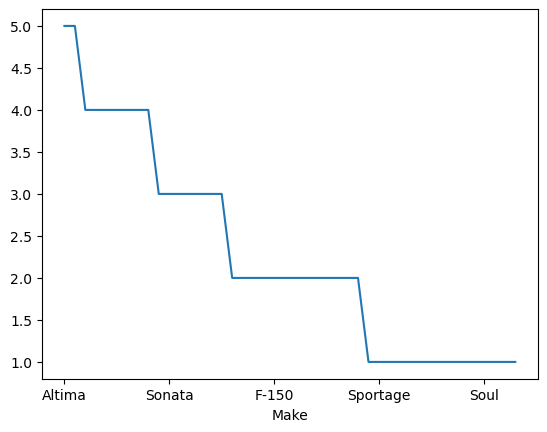

In [136]:
df['Make'].value_counts().plot(kind='line') # kind=bar,line,pie

<Axes: xlabel='Make'>

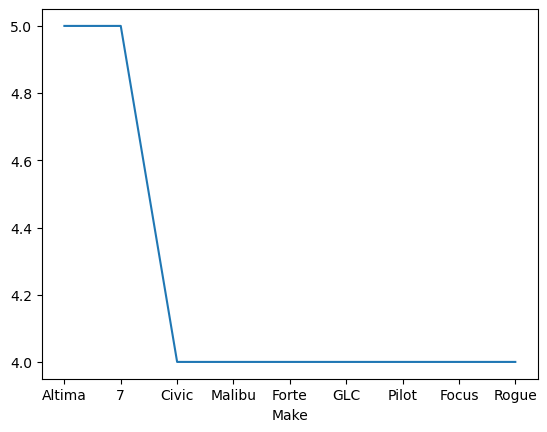

In [144]:
df['Make'].value_counts().head(9).plot(kind='line')

In [150]:
d_f = df[df['Make'] == 'Altima']

In [151]:
print(d_f)

      Make   Model  Year  Mileage  Condition     Price
2   Altima  Altima  2021   138965       Good  18948.47
8   Altima  Altima  2021    31746       Good  33882.86
12  Altima  Altima  2019   108455  Excellent  24227.89
49  Altima  Altima  2018   106510       Fair  18232.47
85  Altima  Altima  2013    84613       Good  16766.17


In [148]:
df

,Make,Model,Year,Mileage,Condition,Price
0,Traverse,Traverse,2010,20830,Excellent,31337.87
1,5,5 Series,2018,149501,Poor,26921.01
2,Altima,Altima,2021,138965,Good,18948.47
3,S-Class,S-Class,2020,117381,Excellent,57825.61
4,Malibu,Malibu,2015,48333,Excellent,35050.24
...,...,...,...,...,...,...
95,Forte,Forte,2010,9308,Good,18394.42
96,Kona,Kona,2021,6949,Good,34738.72
97,Traverse,Traverse,2020,133222,Good,26953.05
98,Tucson,Tucson,2012,101235,Excellent,14240.95


In [156]:
car_data

,Make,Model,Year,Mileage,Condition,Price
0,Chevrolet,Traverse,2010,20830,Excellent,31337.87
1,BMW,5 Series,2018,149501,Poor,26921.01
2,Nissan,Altima,2021,138965,Good,18948.47
3,Mercedes,S-Class,2020,117381,Excellent,57825.61
4,Chevrolet,Malibu,2015,48333,Excellent,35050.24
...,...,...,...,...,...,...
95,Kia,Forte,2010,9308,Good,18394.42
96,Hyundai,Kona,2021,6949,Good,34738.72
97,Chevrolet,Traverse,2020,133222,Good,26953.05
98,Hyundai,Tucson,2012,101235,Excellent,14240.95


In [158]:
df

,Make,Model,Year,Mileage,Condition,Price
0,Chevrolet,Traverse,2010,20830,Excellent,31337.87
1,BMW,5 Series,2018,149501,Poor,26921.01
2,Nissan,Altima,2021,138965,Good,18948.47
3,Mercedes,S-Class,2020,117381,Excellent,57825.61
4,Chevrolet,Malibu,2015,48333,Excellent,35050.24
...,...,...,...,...,...,...
95,Kia,Forte,2010,9308,Good,18394.42
96,Hyundai,Kona,2021,6949,Good,34738.72
97,Chevrolet,Traverse,2020,133222,Good,26953.05
98,Hyundai,Tucson,2012,101235,Excellent,14240.95
